# HEART RATE ESTIMATION

Seismocardiography([SCG](https://www.ncbi.nlm.nih.gov/pubmed/24111357)) is a very promising technique to measure Heart Rate (HR) and Respiratory Rate (RR) with the detector positioned above sternum. It is generally based on accelerometer and gyroscope readings or a combination of them. 

Ballistocardiography([BCG](https://en.wikipedia.org/wiki/Ballistocardiography)) is an another technique to estimate heart and respiratory rate with combination of both accelerometer and gyroscope. It is an indirect evaluation of HR and RR since the contact between the device and the body of the subject is not required (e.g., accelerometer platform mounted under the slats of the bed).   
  
MuSe(Multi-Sensor miniaturized, low-power, wireless [IMU](https://en.wikipedia.org/wiki/Inertial_measurement_unit)) is an Inertial Measurement Unit (IMU) provide by [221e](https://www.221e.com). In the context of this project, It allows to record the inertial data necessary for the estimation of SCG and BCG.

The goal of this assignment is to estimate the heart rate of an healthy subject, given linear acceleration and angular velocity measurements recorded by using the aforementioned MuSe platform. 
The study must be performed on two datasets: the first is the compulsory one (**center_sternum.txt**) while the second is left at the discretion of the group, among those made available for the assignment.

**N.B: Remember that normal beat is around [40-100] bpm.**


## Dataset

The data is provided in .txt file. During this study two healthy subjects were involved with their informed consent. The first dataset was recorded on one subject, while all the other datasets were recorded on the second subject. 

This is the first mandatory file:

* **center_sternum.txt**: MuSe placed on the center of the sternum. The subject was lying supine on his left and right side, respectively. 


Choose one of the following files in order to complete the task.

1. **1_Stave_supine_static.txt**: Sensor placed on a bed stave, under the mattress at the level of the chest. The subject was lying supine on his left and right side. 
* **2_Mattress_supine.txt**: Sensor placed on the mattress, near one corner but not under the pillow. The subject laid in the same position as above. 
* **3_Subject_sitting_chair.txt**: Sensor placed on the desk: the subject, sitting on a chair, leaned forearms and hands on the desk. 
* **4_Chest_sweater.txt**: Sensor placed on the subject chest directly on a sweater. 
* **5_Under_chair.txt**: Subject sitting on a chair, sensor placed under the seat of the chair. 

All .txt files give 16 columns index, in particular: 

* Log Freq stands for the acquisition  in Hz (i.e., sampling interval is constant).
* AccX, AccY, AccZ are the measured magnitude of linear acceleration along each axis.
* GyroX, GyroY, GyroZ are the measured magnitude of angular velocity along each axis.
* MagnX, MagnY, MagnZ are the measured magnitude of magnetic field along each axis.
* qw, qi, qj, qk are the quaternion components, representing the spatial orientation of the Muse system.

Each dataset includes, in addition to the data, one file containing the adopted configuration of the MuSe(**README1.txt** for the first measurement, and in **README_5.txt** for the other measurement).
 


## Assignment



1. Data preparation:

    1.1. Load the txt file and select only the columns you are interesting in, in order to do a complete data analysis (e.g. Log Freq, AccX, ... )
    
    1.2. Plot selected data in function of time and choose a properly time window over which to perform the analysis. Pay attention on time rappresentation and the measurament unit.
    
    1.3. In order to make an appropiate work, decide if take care about some particular axis or some combination of them as well as derived features for the next step of the task. Motivate your choice.  


    
2. Time and frequency analysis:

    2.1. Statistical analysis: provide a statistical description of the chosen dataset. Statistical descriptors includes for example mean, median, variance, standard deviation, 25th and 75th percentiles, and correlation coefficients. Investigate what could be the most interesting descriptors for this type of data, motivating the choices.
    
    2.2. Fourier Analysis: Perform a frequency analysis of the data. Look at the spectrum and explain what you see. Use this step in order to properly design the filters in the following step. 



3. Filter:
    
    Implement your own filter, trying to extrapolate heart rate signal. Hint:
    
    (a) Directly from Fourier Analysis, antitrasform data looking for the most interesting frequency band.
    
    (b) Choose the appropriate Lowpass/Bandpass/Highpass filter.
    
    (c) Wavelet trasform (a powerfull instrument that make a time and frequency analysis of signal).
    
    (d) Find another method by yourselves.
    
    Motivate your choice.
    
    
4. Metrics:

    4.1. Heart Beat Per Minute(BPM): extrapolate BPM, make an histogram of the result. Does it follow a partiular distribution? 
    
    4.2. Heart Rate Variability(HRV): extrapolate HRV, explain why this parameter is important, and plot the results.



5. (OPTIONAL) Algorithm: Elaborate a simple algorithm to extrapolate heart beat even when filter failed (e.g. look at particular threshold...).  



6. Conclusion: 

    Summarise the obtained results, in particular making a comparison between the two files analysed. Highlight limitation and critical issues encountered during the work, motivating the most relevant contribution given by your solution.




**N.B: Indicate the contribution, to achieving the result, of each member of the group.**


# Project execution

The human body constantly emmits life signs that can be detected with inertial sensors, such as accelerometers, gyroscopes, and magnetometers. In practice, these sensors are integrated through a device called an Inertial Measurement Unit (IMU) that allows, for example, tracing the heart activity thanks to small body movements caused by the contraction and relaxation of the heart. 

This way to monitor the heart is known as ballistocardiography (BCG) or seismocardiography (SCG). In simple terms, BCG and SCG are both are non-invasive techniques used to monitor the human heart, based on its mechanical activity. These techniques record the micromovements induced by cardiovascular activity at the body’s center of mass and on the chest.

<center>
  <img src="/example.png" width="40%">
</center>

**Sources:**

* Haescher, M., Matthies, D. J., Trimpop, J., & Urban, B. (2015, June). A study on measuring heart-and respiration-rate via wrist-worn accelerometer-based seismocardiography (SCG) in comparison to commonly applied technologies. In Proceedings of the 2nd international Workshop on Sensor-based Activity Recognition and Interaction (pp. 1-6).

* Balali, P., Rabineau, J., Hossein, A., Tordeur, C., Debeir, O., & Van De Borne, P. (2022). Investigating cardiorespiratory interaction using ballistocardiography and seismocardiography—a narrative review. Sensors, 22(23), 9565.

In the following project, we estimate the heart rate of two healthy subjects.
The measurements were done by using a *MuSe (Multi-Sensor miniaturized, low-power, wireless IMU)*, which recorded all the inertial data necessary for the estimation of SCG and BCG.

## Libraries over the process

Here, we are making a list of the libraries we consider necesary for the development of the project analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import scipy as sp

c:\Users\andre\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.stats import gaussian_kde


## Data preparation

*So, as the mandatory file has to be loaded, we will keep it appart, for the other ones, as we think is fundamental to take a look over the data, we ar going to get info and basic review over the multiple datasets, and maybe a superficial search of correlation between them*



### Dictionary of variables for reference
cs :  Main dataset of center_sternum . the manatory one


chest : Df chest sweater 

In [4]:
path=r'C:\Users\andre\Documents\PADOVA 2025_1\Lab_comp_physics\Project HRE'

In [5]:
cs=pd.read_csv(path+'/center_sternum.txt',sep='\t')
cs.info()
chest=pd.read_csv(path+'/4_Chest_sweater.txt',sep='\t')
chest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16506 entries, 0 to 16505
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Log Mode   16506 non-null  int64  
 1   Log Freq   16506 non-null  int64  
 2   Timestamp  16506 non-null  int64  
 3   AccX       16506 non-null  float64
 4   AccY       16506 non-null  float64
 5   AccZ       16506 non-null  float64
 6   GyroX      16506 non-null  float64
 7   GyroY      16506 non-null  float64
 8   GyroZ      16506 non-null  float64
 9   MagnX      16506 non-null  int64  
 10  MagnY      16506 non-null  int64  
 11  MagnZ      16506 non-null  int64  
 12  qw         16506 non-null  float64
 13  qi         16506 non-null  float64
 14  qj         16506 non-null  float64
 15  qk         16506 non-null  float64
dtypes: float64(10), int64(6)
memory usage: 2.0 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14938 entries, 0 to 14937
Data columns (total 16 columns):
 #   Column

Because the most common wearable systems for detecting muscle activity are based on accelerometry (Haescher, 2015)...


In [6]:
chest = chest[["Timestamp", "AccX", "AccY", "AccZ"]].copy()
chest

,Timestamp,AccX,AccY,AccZ
0,1555414552,687.836,380.823,580.354
1,1555414552,-812.703,-108.946,726.876
2,1555414552,-812.520,-108.824,733.952
3,1555414552,-787.144,-45.628,616.954
4,1555414552,-800.259,-137.433,411.689
...,...,...,...,...
14933,1555415471,-890.722,-81.008,446.764
14934,1555415471,-885.964,-76.006,459.025
14935,1555415471,-879.681,-77.714,475.068
14936,1555415471,-894.992,-76.311,502.701


Plots of acceleration in axis and angular veloxity in axis ( gyroscope measures velocity) For both 

Text(0.5, 1.0, 'Acceleration in axis for "chest swater"')

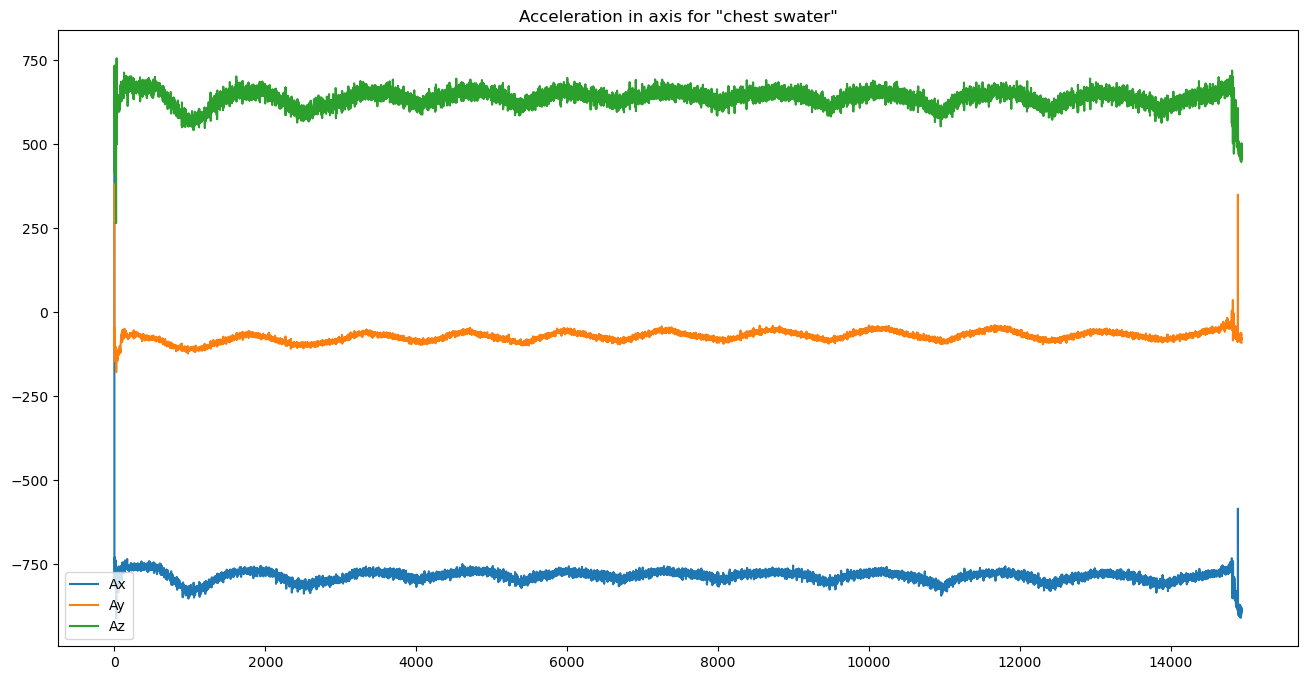

In [7]:
plt.figure(figsize=(16, 8))
plt.plot(chest['AccX'],label='Ax')
plt.plot(chest['AccY'],label='Ay')
plt.plot(chest['AccZ'],label='Az')
plt.legend()
plt.title('Acceleration in axis for "chest swater"')

Text(0.5, 1.0, 'Acceleration in axis for "center sternum MuSe"')

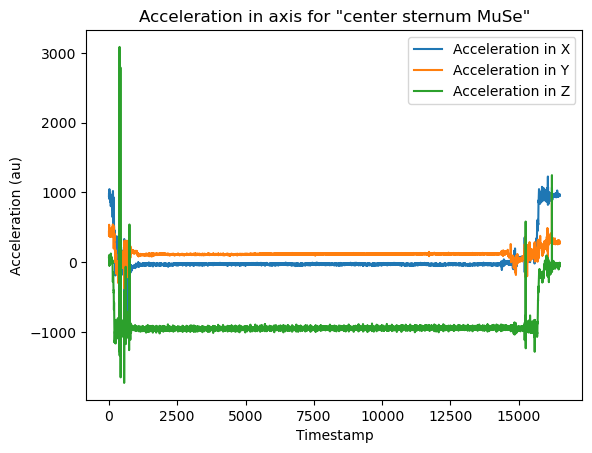

In [8]:

plt.plot( cs['AccX'],label='Acceleration in X')
plt.plot(cs['AccY'],label='Acceleration in Y')
plt.plot(cs['AccZ'],label='Acceleration in Z')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration (au)')
plt.legend()
plt.title('Acceleration in axis for "center sternum MuSe"')

The initial and terminal spikes in the accelerometer data likely represent motion artifacts from when the sensor was first attached and finally removed. For that reason, we plot a zoom...

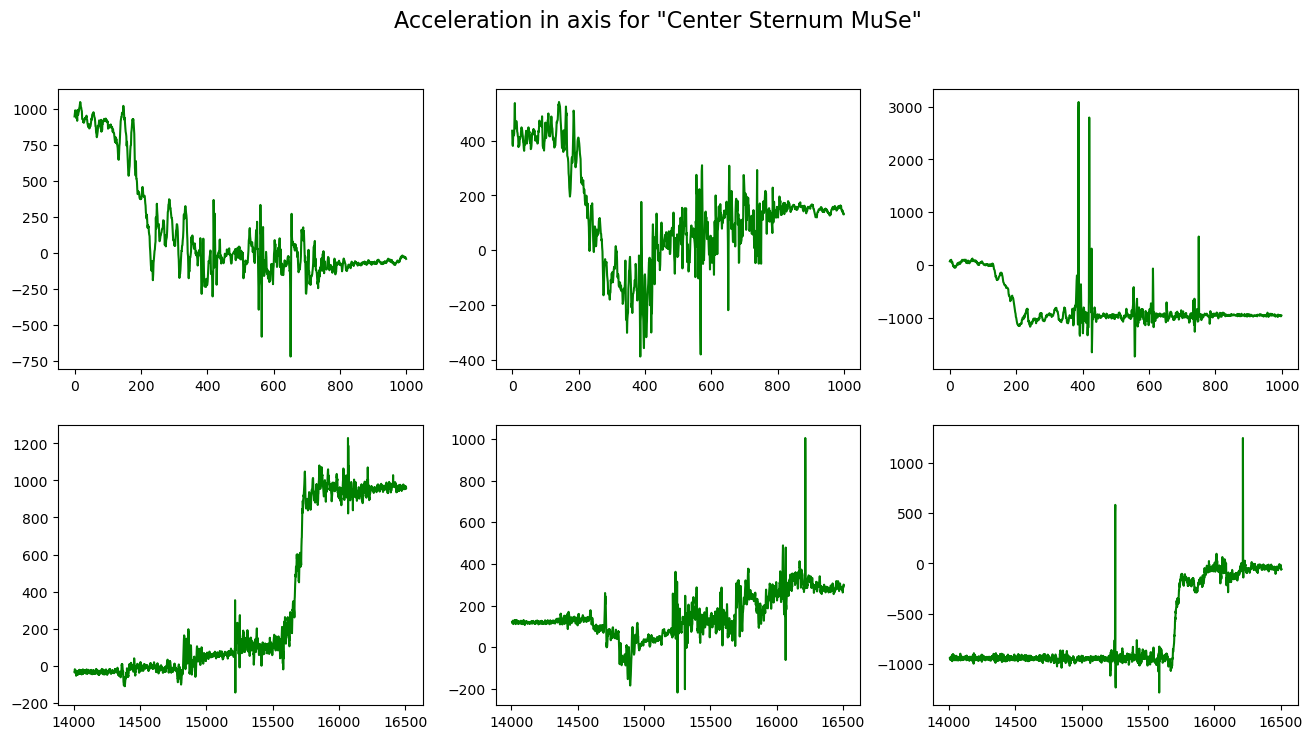

In [9]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Acceleration in axis for "Center Sternum MuSe"', fontsize=16)
ax1.plot(cs["AccX"][:1000],color='green')
ax2.plot(cs["AccY"][:1000],color='green')
ax3.plot(cs["AccZ"][:1000],color='green')

ax4.plot(cs["AccX"][-2500:],color='green')
ax5.plot(cs["AccY"][-2500:],color='green')
ax6.plot(cs["AccZ"][-2500:],color='green')

plt.show()

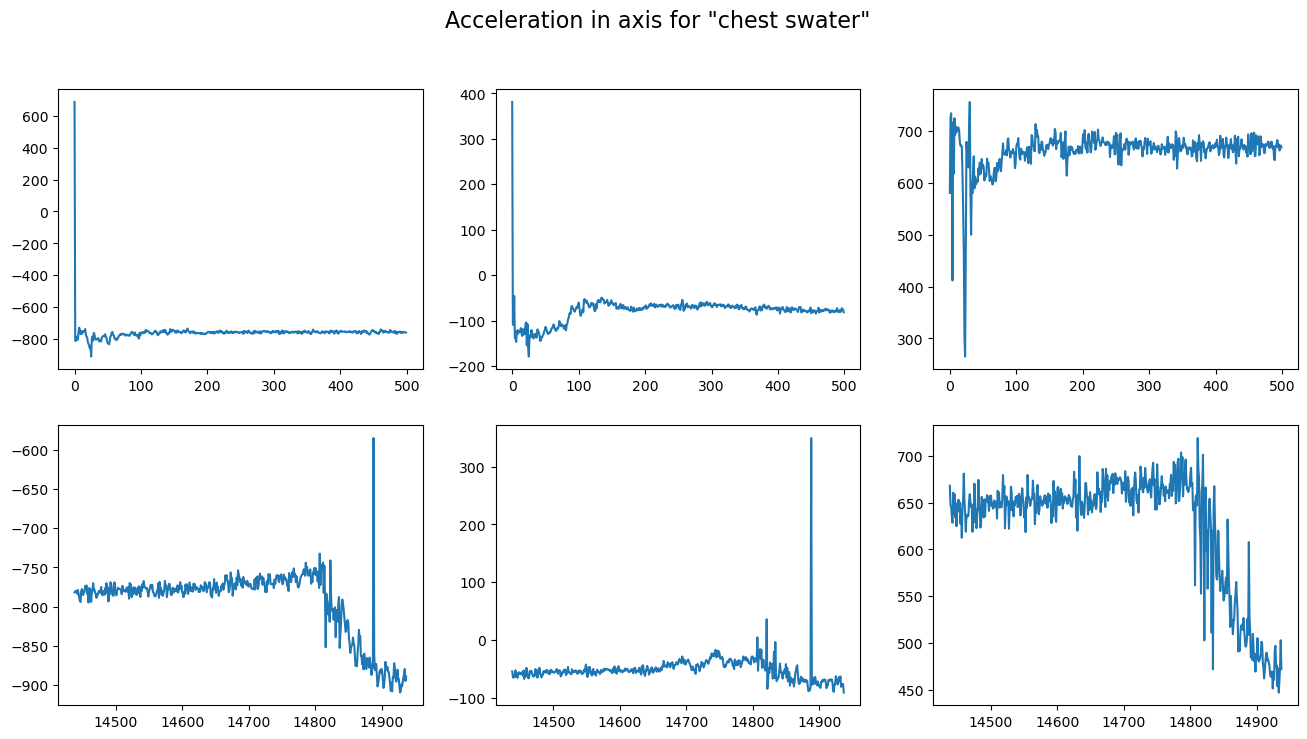

In [10]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Acceleration in axis for "chest swater"', fontsize=16)
ax1.plot(chest["AccX"][:500])
ax2.plot(chest["AccY"][:500])
ax3.plot(chest["AccZ"][:500])

ax4.plot(chest["AccX"][-500:])
ax5.plot(chest["AccY"][-500:])
ax6.plot(chest["AccZ"][-500:])

plt.show()

*Based on this graphs, the data will be analyzed from x:x in A and x:x in B*

In [11]:
chest_clean = chest[200:-200].copy()
cs_clean=cs[850:-2500].copy()

Following Haescher(2015), a combined signal from the three axes was generated by computing the magnitude of the acceleration vector: $$a= \sqrt{a_x^2 + a_y^2 +az^2}$$

In [12]:
cs_clean['MagAcc']=np.sqrt(cs_clean['AccX']**2 + cs_clean['AccY']**2 + cs_clean['AccZ']**2)
chest_clean['MagAcc'] = np.sqrt(chest_clean['AccX']**2 + chest_clean['AccY']**2 + chest_clean['AccZ']**2)

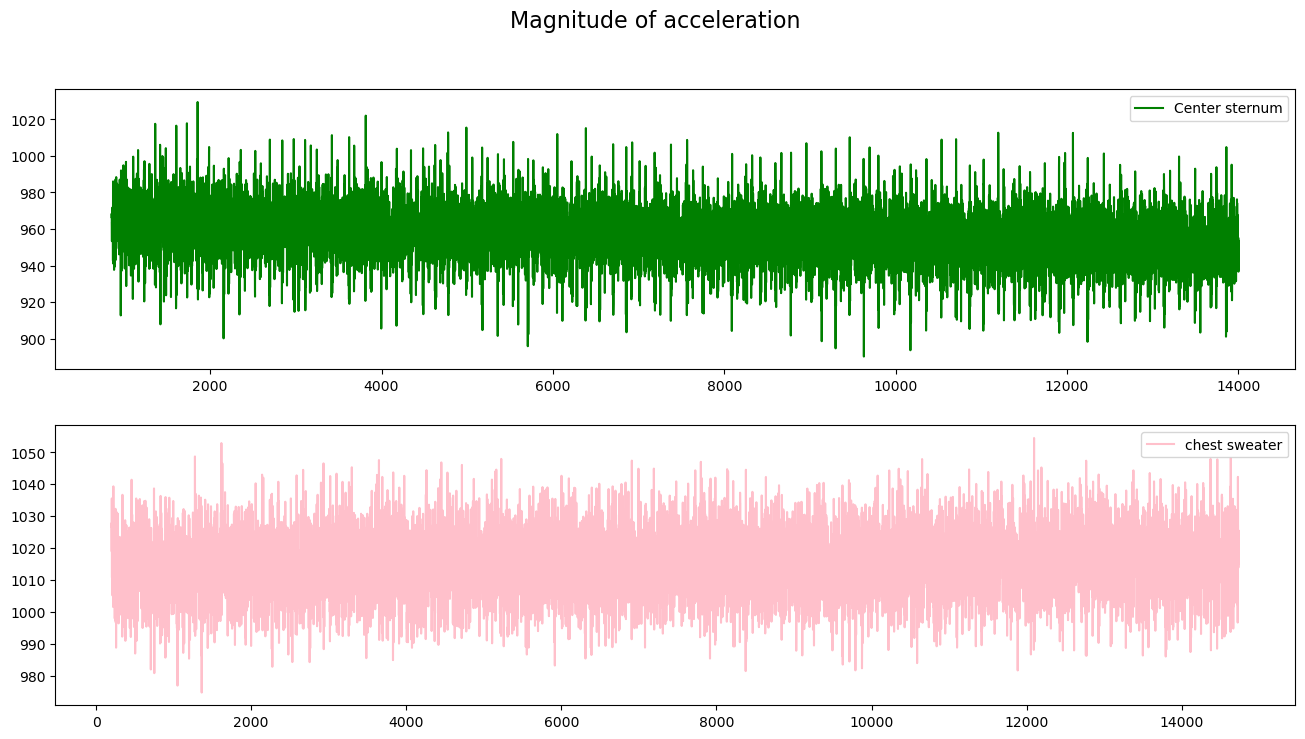

In [13]:
fig, (ax2,ax1) = plt.subplots(2,figsize=(16, 8))

ax1.plot(chest_clean['MagAcc'],color='pink', label='chest sweater')
ax1.legend()

ax2.plot(cs_clean['MagAcc'], color='green', label='Center sternum')
fig.suptitle('Magnitude of acceleration', fontsize=16)
ax2.legend()


## Time and frequency analysis
### Calibration for the data

2. Time and frequency analysis:

    2.1. Statistical analysis: provide a statistical description of the chosen dataset. Statistical descriptors includes for example mean, median, variance, standard deviation, 25th and 75th percentiles, and correlation coefficients. Investigate what could be the most interesting descriptors for this type of data, motivating the choices.
    
    2.2. Fourier Analysis: Perform a frequency analysis of the data. Look at the spectrum and explain what you see. Use this step in order to properly design the filters in the following step. 

*Initially this is the calibration over the chest_swater is necesary to do it also for the Center sternum*

In [38]:
freq_cs = cs_clean['Timestamp'].value_counts().mean()
freq_chest=chest_clean['Timestamp'].value_counts().mean()

In [41]:
chest_clean

,Timestamp,AccX,AccY,AccZ,MagAcc,Absolut_Time
200,1555415326,-761.768,-69.113,684.969,1026.766587,0.000000
201,1555415326,-755.302,-66.246,693.997,1027.862578,0.009908
202,1555415326,-757.315,-73.993,677.649,1018.925483,0.019815
203,1555415326,-758.535,-70.516,701.439,1035.550348,0.029723
204,1555415326,-762.439,-71.614,668.926,1016.810596,0.039630
...,...,...,...,...,...,...
14733,1555415469,-771.284,-41.358,674.599,1025.511240,143.987415
14734,1555415469,-771.223,-38.247,671.000,1022.980327,143.997322
14735,1555415469,-771.711,-33.428,663.985,1018.592843,144.007230
14736,1555415469,-771.406,-29.402,660.813,1016.171991,144.017138


In [44]:

print('The frequency of Chest Sweater is:', freq_chest, 'HZ and its  data statistics: \n',chest_clean[['AccX', 'AccY', 'AccZ','MagAcc']].describe())

print('\n The frequency of Center Sternum is:', freq_cs , 'Hz and its data statistics: \n', cs_clean[['AccX', 'AccY', 'AccZ','GyroX','GyroY','GyroZ','MagAcc']].describe())

The frequency of Chest Sweater is: 100.95833333333333 HZ and its  data statistics: 
                AccX          AccY          AccZ        MagAcc
count  14538.000000  14538.000000  14538.000000  14538.000000
mean    -786.171403    -72.807067    637.319474   1015.077661
std       14.902281     14.065378     22.515453      9.305875
min     -852.658000   -123.098000    541.497000    974.712342
25%     -795.379000    -81.923000    624.213000   1009.379657
50%     -783.911000    -72.346000    640.256000   1015.102283
75%     -775.798000    -62.342000    652.822000   1020.835846
max     -740.906000    -28.548000    702.354000   1054.479885

 The frequency of Center Sternum is: 212.19354838709677 Hz and its data statistics: 
                AccX          AccY          AccZ         GyroX         GyroY  \
count  13156.000000  13156.000000  13156.000000  13156.000000  13156.000000   
mean     -31.259695    115.549820   -949.678175     -2.036007      3.728004   
std        8.186421      7.125134

In [67]:
# The datetime module supplies classes for manipulating dates and times

ts = 1555415326 # 2019-04-16 13:48:46
#ts = 1555415469	# 2019-04-16 13:51:09
fecha_humana = datetime.datetime.fromtimestamp(ts)
# fromtimestamp() Function Of Datetime.date Class In Python. 
# fromtimestamp() function in Python is used to return the date corresponding to a specified timestamp.

# I read and there are different types of timestamps.
# Apparently the one we have is in a format called unix time stamp.
# Basically is a way to track time as a running total of seconds. The count starts on January 1st, 1970 at UTC

# To be sure we print the date and it is indeed the same it is in the README file.
print(fecha_humana)

2019-04-16 06:48:46


However is not that easy to convert to seconds because the device has a certain frequency (100 Hz), meaning that it makes around 100 samples each seconds, so we have many records for the same timestamp.

In [68]:
conteos = chest['Timestamp'].value_counts()

#freq = chest['Timestamp'].value_counts().mean()
chest_clean['Absolut_Time'] = np.arange(len(chest_clean))/freq_chest # numero de la muestra / frequencia 
chest_clean.head()
# makes sense bc there are around 143 seconds between 2019-04-16 13:48:46 and 2019-04-16 13:51:09
# probably its better to do this before cutting the data.

,Timestamp,AccX,AccY,AccZ,MagAcc,Absolut_Time
200,1555415326,-761.768,-69.113,684.969,1026.766587,0.000000
201,1555415326,-755.302,-66.246,693.997,1027.862578,0.009905
202,1555415326,-757.315,-73.993,677.649,1018.925483,0.019810
203,1555415326,-758.535,-70.516,701.439,1035.550348,0.029715
204,1555415326,-762.439,-71.614,668.926,1016.810596,0.039620


## Fourier Analysis

We are aplying the scipy library for the aplication of the fourier analysis

Text(0.5, 1.0, 'Spectrum of frequencies Center Sternum  Acceleration')

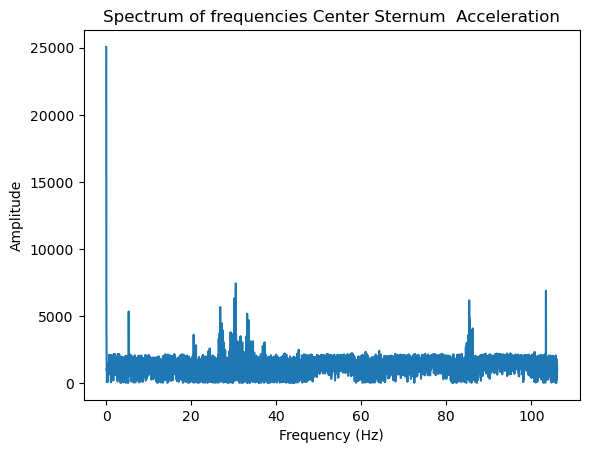

In [70]:
# This one is for the  CS
dt =1/freq_cs  
cs_fft=sp.fft.fft(np.array(cs_clean['MagAcc']))
cs_fft=np.abs(cs_fft)-np.mean(np.abs(cs_fft))
cs_freq=sp.fft.fftfreq(len(cs_clean['MagAcc']),d=dt)
mask=cs_freq>0
plt.plot(cs_freq[mask], np.abs(cs_fft[mask]))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectrum of frequencies Center Sternum  Acceleration')


Text(0.5, 1.0, 'Spectrum of frequencies Chest Sweater Acceleration')

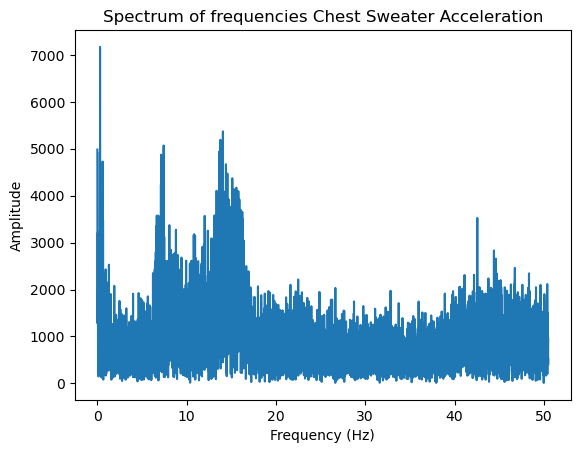

In [72]:
chest_signal = np.array(chest_clean['MagAcc'])-np.mean(np.array(chest_clean['MagAcc']))
chest_fft= sp.fft.fft(chest_signal)
#chest_fft= np.abs(chest_fft)- np.mean(np.abs(chest_fft)) 
chest_fft=np.abs(chest_fft)
N = len(chest_clean['MagAcc'])

#dt = 0.009908  

freq = np.fft.fftfreq(N,d=1/freq_chest)
mask=freq>0
plt.plot(freq[mask], np.abs(chest_fft[mask]))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('Spectrum of frequencies Chest Sweater Acceleration')


In [62]:
idx = np.argmax(chest_fft[mask])
print(idx)
freq_dominante = freq[idx]
print(freq_dominante,'This one should be the respiration rate ')

subset_heart=(freq>0.9) & (freq<2.5)
idx = np.argmax(chest_fft[subset_heart])
print(idx)
freq_heart = freq[subset_heart][idx]
print(freq_heart,'This one should be the heart rate')

plt.plot(freq[subset_heart], chest_fft[subset_heart])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
#plt.axvline(x=freq_heart, color='red', linestyle='--', label=f'Heart Rate: {freq_heart:.2f} Hz')
plt.axhline(y=chest_fft[subset_heart][idx], color='red', linestyle='--')
plt.title('Heart rate frequency range')




44
2.997821980132957e-05 This one should be the respiration rate 


ValueError: attempt to get argmax of an empty sequence

In [ ]:
print(freq_dominante)

0.31240778763468313
